# Conhecendo os Dados: Trump vs AOC no Twitter/X
## Um Primeiro Olhar Sobre Como Dois Políticos Usam as Redes Sociais

---

### Por Que Estamos Analisando Esses Dados?

As redes sociais se tornaram um dos espaços mais importantes para a comunicação política no século XXI. Os políticos não dependem mais exclusivamente de coletivas de imprensa, entrevistas na televisão ou jornais partidários para alcançar suas audiências. Em vez disso, plataformas como o Twitter/X permitem que falem diretamente com milhões de pessoas, contornando os filtros da mídia tradicional.

Neste estudo, utilizamos um método chamado **netnografia** -- uma forma de estudar comunidades online e cultura digital, semelhante a como um antropólogo estudaria uma vila ou um historiador analisaria um conjunto de fontes primárias. Em vez de cartas, discursos ou arquivos de jornais, nossas "fontes primárias" aqui são tweets: mensagens públicas curtas postadas por dois políticos americanos proeminentes.

Estamos comparando **Donald Trump** (Republicano, ex-presidente) e **Alexandria Ocasio-Cortez / AOC** (Democrata, congressista) para entender:

- **Como** eles usam as redes sociais de maneira diferente (horários de postagem, formatos, estilos)
- **O que** essas diferenças nos dizem sobre suas estratégias de comunicação
- **Por que** isso importa para entender a cultura política contemporânea

Pense neste notebook como sua primeira visita ao arquivo. Estamos abrindo as caixas, contando os documentos e tendo uma noção do que temos em mãos antes de começar a interpretar.

---

### O Que Este Notebook Cobre

1. **Visão geral do dataset** -- Quantos dados temos? Como eles se apresentam?
2. **Quando eles tweetam?** -- Horário do dia, dia da semana e padrões de fim de semana
3. **Que tipos de tweets eles postam?** -- Posts originais vs. respostas vs. repostagens
4. **Que formatos eles usam?** -- Apenas texto, fotos, vídeos, etc.
5. **Qual o tamanho dos tweets?** -- Contagem de caracteres e palavras
6. **Tabela resumo** -- Uma comparação lado a lado dos números principais
7. **Principais conclusões** -- O que aprendemos com este primeiro olhar

---

### Alguns Termos Que Você Verá

Antes de começarmos, aqui estão alguns termos que aparecerão ao longo do notebook:

- **Média**: Some todos os números e depois divida pela quantidade deles. Por exemplo, se três tweets têm 10, 20 e 30 curtidas, a média é 20.
- **Mediana (valor do meio)**: Se você organizar todos os números do menor para o maior, a mediana é aquele que fica bem no meio. Isso é útil porque alguns tweets extremamente populares podem tornar a média enganosa.
- **Desvio padrão (quão espalhados os números estão)**: Um número maior significa mais variação. Se todos os tweets recebem aproximadamente o mesmo número de curtidas, o desvio padrão é baixo. Se alguns tweets recebem 100 curtidas e outros recebem 1 milhão, ele é alto.
- **Taxa de engajamento = total de interações / visualizações**: Qual porcentagem das pessoas que viram um tweet realmente fez algo com ele (curtiu, repostou, respondeu, etc.).
- **Distribuição (como os dados se espalham pelos diferentes valores)**: Pense nisso como um histograma -- um gráfico de barras mostrando onde a maioria dos valores se concentra. A maioria dos tweets é curta, ou existe uma ampla variedade de tamanhos?

In [1]:
# --- Configuração: imports e configuração ---

import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils.data_loader import load_tweets, load_replies
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_boxplot, comparative_hist,
    format_large_numbers, set_language
)
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED

# Aplicar estilo consistente
setup_style()
set_language('pt-br')
colors = get_colors()
np.random.seed(RANDOM_SEED)

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Configuração concluída.')

Configuração concluída.


In [2]:
# --- Carregar dados ---

df = load_tweets()
replies_df = load_replies()

print(f"\nFormato dos tweets:  {df.shape}")
print(f"Formato das respostas: {replies_df.shape}")

Loaded 200 tweets from processed/
Loaded 11403 replies from processed/

Formato dos tweets:  (200, 42)
Formato das respostas: (11403, 19)


## 1. Como É o Nosso Dataset?

Antes de analisar qualquer coisa, precisamos fazer um inventário. Quantos tweets temos? Que período de tempo eles cobrem? Há alguma informação faltando?

Pense nesta etapa como um historiador abrindo uma caixa de arquivo pela primeira vez: você conta os documentos, verifica se há lacunas e anota o período abrangido antes de começar a ler.

In [3]:
# --- Visão geral do dataset ---

# Formato básico
print("=" * 60)
print("VISÃO GERAL DO DATASET")
print("=" * 60)
print(f"\nTotal de tweets: {len(df)}")
print(f"Total de respostas coletadas: {len(replies_df)}")
print(f"Número de colunas (tipos de informação por tweet): {df.shape[1]}")

# Detalhamento por usuário
print("\n--- Tweets por Usuário ---")
user_counts = df['user'].value_counts()
for user, count in user_counts.items():
    label = get_user_label(user)
    print(f"  {label}: {count} tweets")

# Intervalo de datas
print("\n--- Período Coberto ---")
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    label = get_user_label(user)
    min_date = user_df['created_at'].min()
    max_date = user_df['created_at'].max()
    date_range = (max_date - min_date).days
    print(f"  {label}:")
    print(f"    De:      {min_date.strftime('%Y-%m-%d %H:%M')}")
    print(f"    Até:     {max_date.strftime('%Y-%m-%d %H:%M')}")
    print(f"    Período: {date_range} dias")

# Valores ausentes
print("\n--- Informações Ausentes (principais colunas) ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'contagem': missing, 'pct': missing_pct})
missing_report = missing_report[missing_report['contagem'] > 0].sort_values('contagem', ascending=False)
if len(missing_report) > 0:
    print(missing_report.head(10).to_string())
else:
    print("  Nenhum valor ausente encontrado.")

# Resumo dos tipos de dados
print("\n--- Tipos de Dados das Colunas ---")
print(df.dtypes.value_counts().to_string())

# Estatísticas numéricas principais
print("\n--- Números Básicos das Métricas Principais ---")
key_metrics = ['favorite_count', 'retweet_count', 'reply_count', 'view_count',
               'total_engagement', 'engagement_rate']
display(df[key_metrics].describe().round(2))

VISÃO GERAL DO DATASET

Total de tweets: 200
Total de respostas coletadas: 11403
Número de colunas (tipos de informação por tweet): 42

--- Tweets por Usuário ---
  AOC (@AOC): 100 tweets
  Trump (@realDonaldTrump): 100 tweets

--- Período Coberto ---
  Trump (@realDonaldTrump):
    De:      2025-04-01 20:53
    Até:     2026-02-03 02:29
    Período: 307 dias
  AOC (@AOC):
    De:      2026-01-23 22:46
    Até:     2026-02-26 15:32
    Período: 33 dias

--- Informações Ausentes (principais colunas) ---
                    contagem   pct
hashtags_extracted       197 98.50
image_paths              171 85.50

--- Tipos de Dados das Colunas ---
int64                  19
float64                 7
bool                    6
str                     5
category                1
datetime64[us, UTC]     1
category                1
object                  1
category                1

--- Números Básicos das Métricas Principais ---


,favorite_count,retweet_count,reply_count,view_count,total_engagement,engagement_rate
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,"178,478.06","26,480.35","17,601.96","28,575,455.98","231,994.54",473.85
std,"234,706.93","27,800.96","26,258.52","39,223,235.33","299,799.81","2,433.32"
min,0.00,193.00,0.00,0.00,193.00,0.00
25%,0.00,"4,628.50",0.00,327.50,"7,332.50",0.01
50%,"84,716.00","17,398.00","8,032.00","4,306,114.00","112,748.00",0.02
75%,"318,243.00","41,370.00","25,676.00","46,651,766.00","405,181.00",6.79
max,"1,305,554.00","190,264.00","175,348.00","263,732,066.00","1,688,382.00","28,802.50"


### O que isso nos diz?

A tabela acima nos dá uma primeira impressão da escala com que estamos lidando. Observe as colunas: **favorite_count** (curtidas), **retweet_count** (repostagens), **reply_count** (respostas), **view_count** (quantas pessoas viram), **total_engagement** (todas as interações combinadas) e **engagement_rate** (porcentagem de espectadores que interagiram).

Preste atenção em quão diferentes são os valores **mínimos** e **máximos** -- alguns tweets mal recebem atenção, enquanto outros alcançam milhões de pessoas. Essa ampla variação é típica das redes sociais: alguns poucos posts viralizam enquanto a maioria recebe atenção mais modesta.

## 2. Quando Eles Tweetam?

Quando um político escolhe postar é em si uma escolha significativa. Isso sinaliza quando estão ativos, quando acham que sua audiência está prestando atenção, e até como organizam sua rotina diária.

Pense desta forma: se um político tuíta consistentemente às 6h da manhã, pode estar mirando os madrugadores ou o ciclo de notícias matutino. Se tuíta tarde da noite, pode estar falando com uma audiência diferente ou reagindo a eventos em tempo real.

Vamos analisar três padrões temporais: **dia a dia** (o ritmo geral), **hora do dia** (manhã vs. noite), e **dia da semana** (dias úteis vs. fins de semana).

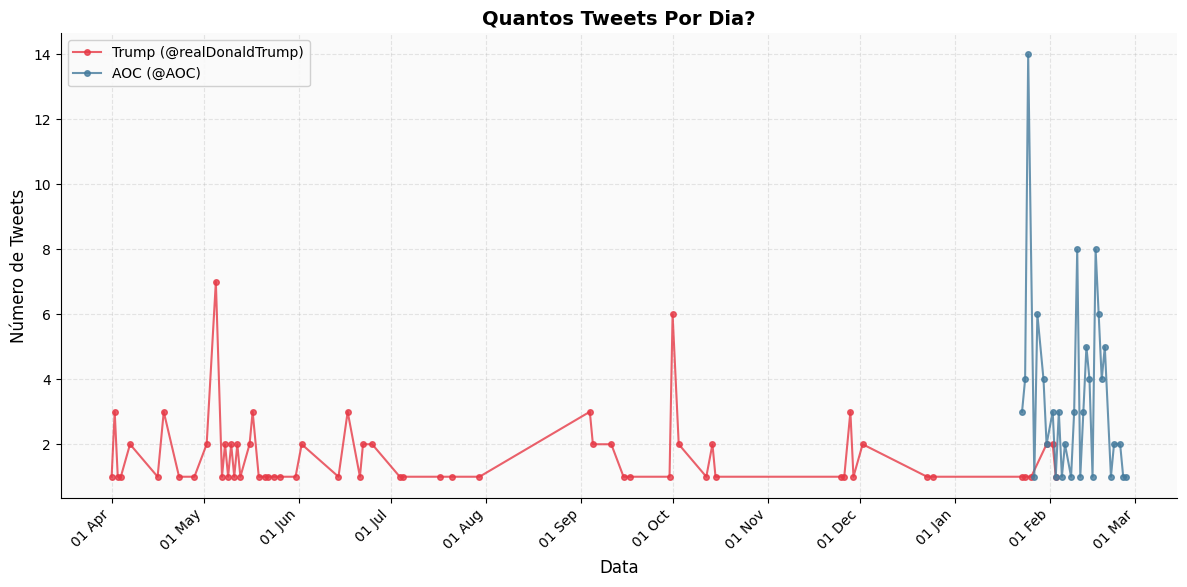

In [4]:
# --- Quantos Tweets Por Dia? ---

# Agregar contagens diárias de tweets por usuário
daily_counts = df.groupby(['date', 'user']).size().reset_index(name='count')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = daily_counts[daily_counts['user'] == user].sort_values('date')
    ax.plot(
        user_data['date'], user_data['count'],
        marker='o', markersize=4, linewidth=1.5, alpha=0.8,
        color=colors[user], label=get_user_label(user)
    )

ax.set_title('Quantos Tweets Por Dia?', fontweight='bold', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Número de Tweets')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico acompanha o volume diário de postagens de cada político ao longo do período coletado. Os picos e vales contam uma história: um pico repentino pode corresponder a um grande evento noticioso, uma controvérsia política ou um impulso de campanha. Um período silencioso pode significar que o político estava viajando, em reuniões ou deliberadamente se mantendo em silêncio.

Compare as duas linhas: um político posta de forma mais consistente dia após dia, ou há altos e baixos mais dramáticos? Consistência vs. rajadas de atividade refletem diferentes estratégias de comunicação -- presença constante vs. engajamento reativo.

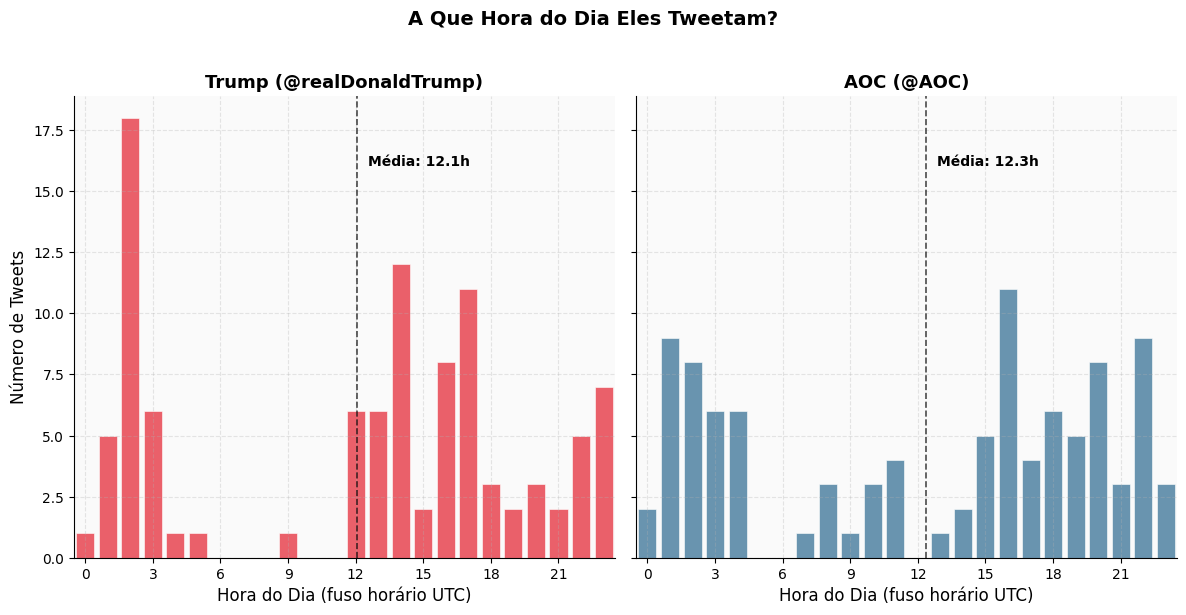

In [5]:
# --- A Que Hora do Dia Eles Tweetam? ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE, sharey=True)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_data = df[df['user'] == user]
    hour_counts = user_data['hour'].value_counts().reindex(range(24), fill_value=0)
    
    ax.bar(
        hour_counts.index, hour_counts.values,
        color=colors[user], alpha=0.8, edgecolor='white', linewidth=0.5
    )
    
    # Marcar a hora média
    mean_hour = user_data['hour'].mean()
    ax.axvline(mean_hour, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(
        mean_hour + 0.5, ax.get_ylim()[1] * 0.85,
        f'Média: {mean_hour:.1f}h',
        fontsize=10, fontweight='bold', color='black'
    )
    
    ax.set_title(get_user_label(user), fontweight='bold', fontsize=13)
    ax.set_xlabel('Hora do Dia (fuso horário UTC)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(-0.5, 23.5)

axes[0].set_ylabel('Número de Tweets')

fig.suptitle('A Que Hora do Dia Eles Tweetam?', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Cada barra representa uma hora do dia (no fuso horário UTC). Quanto mais alta a barra, mais tweets foram postados naquela hora. A linha tracejada mostra a hora média de postagem.

Observe o formato geral: um político é um "tuiteiro matutino" que posta durante o horário comercial, enquanto o outro é uma "coruja noturna" que permanece ativa até tarde? Esses ritmos de postagem refletem diferentes estratégias de alcance de audiência. Um político que tuíta à meia-noite pode estar mirando uma audiência nacional em diferentes fusos horários, reagindo a notícias de última hora, ou simplesmente tuitando por hábito pessoal. Aquele que concentra posts durante o horário comercial pode estar mais coordenado com uma equipe de comunicação.

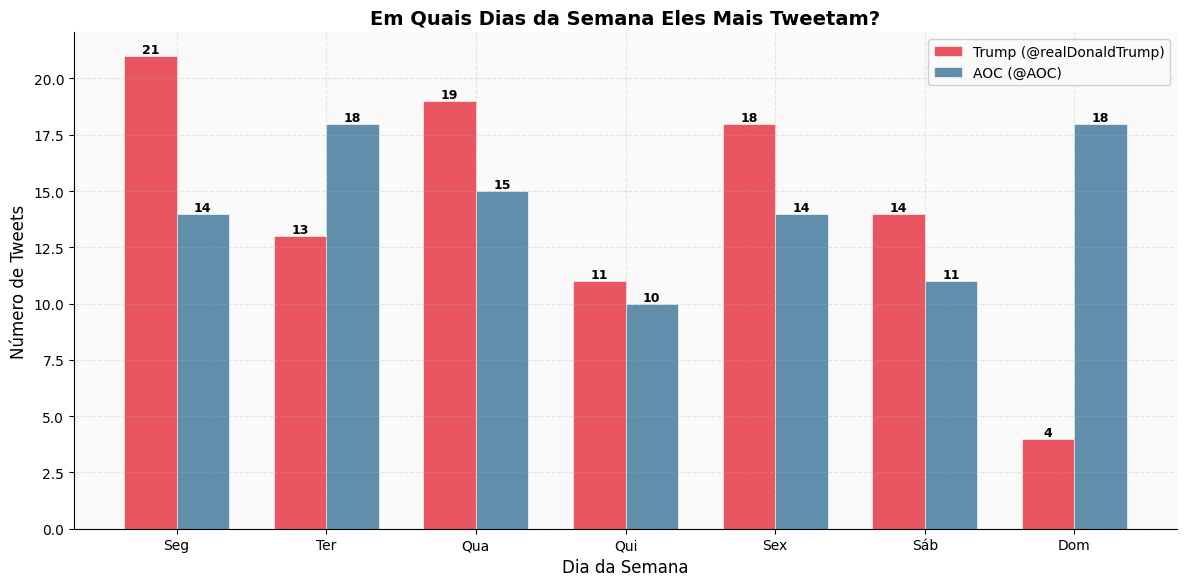

In [6]:
# --- Em Quais Dias da Semana Eles Mais Tweetam? ---

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(day_order))
bar_width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    user_data = df[df['user'] == user]
    day_counts = user_data['day_name'].value_counts().reindex(day_order, fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(
        x + offset, day_counts.values,
        width=bar_width, color=colors[user], alpha=0.85,
        label=get_user_label(user), edgecolor='white', linewidth=0.5
    )
    # Rótulos de valor nas barras
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, height,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

ax.set_title('Em Quais Dias da Semana Eles Mais Tweetam?', fontweight='bold', fontsize=14)
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Número de Tweets')
ax.set_xticks(x)
ax.set_xticklabels(day_abbr)
ax.legend()
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico mostra como a atividade de tuitagem se distribui ao longo da semana. Algumas perguntas para refletir: um político descansa nos fins de semana? O outro intensifica em certos dias? Na política, o ritmo da semana importa -- segunda-feira pode trazer anúncios de políticas, enquanto sexta-feira à noite é tradicionalmente quando políticos divulgam notícias que esperam que sejam ignoradas (uma tática conhecida como "despejo de notícias de sexta-feira").

Se um político tuíta consistentemente todos os dias e o outro se concentra nos dias úteis, isso nos diz algo sobre se eles tratam as redes sociais como um canal pessoal ou profissional.

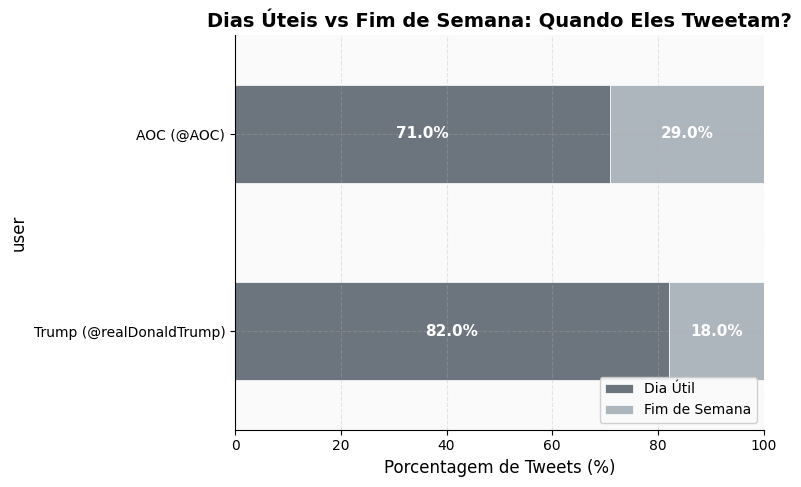

In [7]:
# --- Dias Úteis vs Fim de Semana ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)

weekend_data = []
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    total = len(user_data)
    weekday_pct = (user_data['is_weekend'] == False).sum() / total * 100
    weekend_pct = (user_data['is_weekend'] == True).sum() / total * 100
    weekend_data.append({
        'user': get_user_label(user),
        'Dia Útil': weekday_pct,
        'Fim de Semana': weekend_pct
    })

weekend_df = pd.DataFrame(weekend_data).set_index('user')

# Mapeamento de cores para dia útil/fim de semana
bar_colors = ['#6C757D', '#ADB5BD']

weekend_df.plot(
    kind='barh', stacked=True, ax=ax,
    color=bar_colors, edgecolor='white', linewidth=0.5
)

# Adicionar rótulos de porcentagem em cada segmento
for idx, (_, row) in enumerate(weekend_df.iterrows()):
    # Rótulo do dia útil
    ax.text(
        row['Dia Útil'] / 2, idx,
        f"{row['Dia Útil']:.1f}%",
        ha='center', va='center', fontsize=11, fontweight='bold', color='white'
    )
    # Rótulo do fim de semana
    ax.text(
        row['Dia Útil'] + row['Fim de Semana'] / 2, idx,
        f"{row['Fim de Semana']:.1f}%",
        ha='center', va='center', fontsize=11, fontweight='bold', color='white'
    )

ax.set_title('Dias Úteis vs Fim de Semana: Quando Eles Tweetam?', fontweight='bold', fontsize=14)
ax.set_xlabel('Porcentagem de Tweets (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico divide os tweets de cada político entre postagens em dias úteis e fins de semana. Se um político tuíta intensamente nos fins de semana, isso sugere que sua presença nas redes sociais é mais pessoal ou "sempre ligada". Se se concentram nos dias úteis, pode indicar uma abordagem mais profissional ou gerenciada por equipe.

Para historiadores que estudam comunicação política, essa distinção importa: a fronteira entre comunicação "oficial" e "pessoal" é uma das características definidoras da era das redes sociais.

## 3. Que Tipos de Tweets Eles Postam?

Nem todos os tweets são iguais. No Twitter/X, existem vários tipos:

- **Tweets originais**: Novas postagens que o político escreve por conta própria
- **Respostas**: Reações ao tweet de outra pessoa (uma forma de conversa)
- **Citações**: Compartilhar o tweet de outra pessoa com comentário adicional
- **Repostagens**: Simplesmente compartilhar o tweet de outra pessoa sem adicionar nada

O equilíbrio entre esses tipos revela muito sobre a estratégia de comunicação de um político. Alguém que posta principalmente tweets originais está **transmitindo** -- falando para o público como um megafone. Alguém que frequentemente responde e cita está **participando de uma conversa** -- engajando em um diálogo de ida e volta.

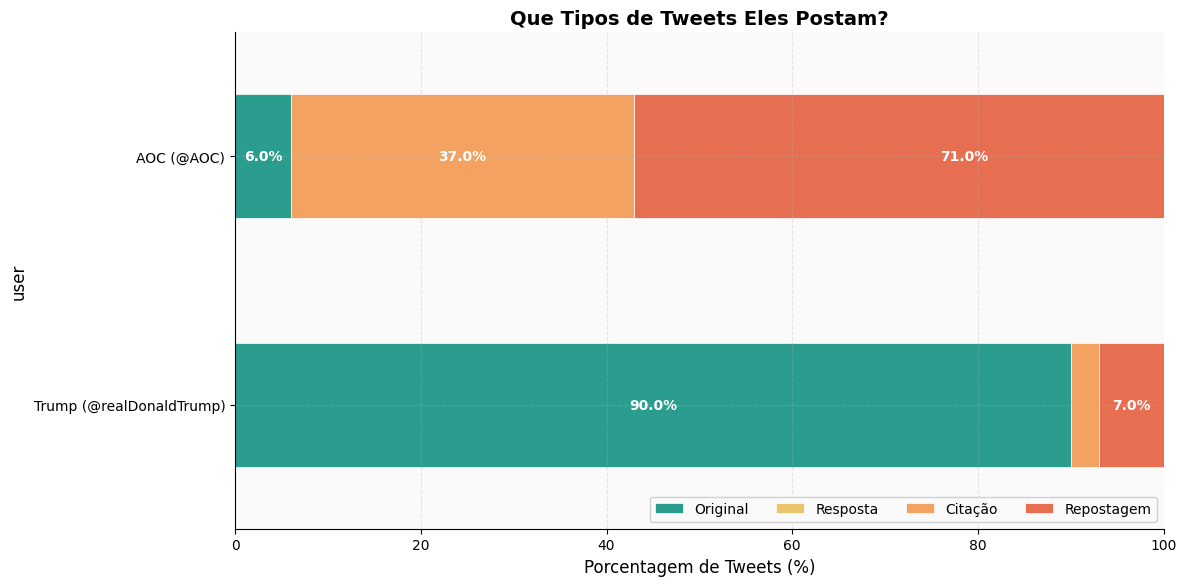


Detalhamento exato dos tipos de tweet:
                          Original  Resposta  Citação  Repostagem
user                                                             
Trump (@realDonaldTrump)     90.00      0.00     3.00        7.00
AOC (@AOC)                    6.00      0.00    37.00       71.00


In [8]:
# --- Que Tipos de Tweets Eles Postam? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

type_data = []
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    total = len(user_data)
    
    # Classificar: retweet > citação > resposta > original
    retweet_pct = user_data['is_retweet'].sum() / total * 100
    quote_pct = user_data['is_quote'].sum() / total * 100
    reply_pct = user_data['is_reply'].sum() / total * 100
    # Original = não é retweet, não é citação e não é resposta
    original_pct = ((~user_data['is_retweet']) & (~user_data['is_quote']) & (~user_data['is_reply'])).sum() / total * 100
    
    type_data.append({
        'user': get_user_label(user),
        'Original': original_pct,
        'Resposta': reply_pct,
        'Citação': quote_pct,
        'Repostagem': retweet_pct
    })

type_df = pd.DataFrame(type_data).set_index('user')

# Paleta de cores para tipos de tweet
type_colors = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

type_df.plot(
    kind='barh', stacked=True, ax=ax,
    color=type_colors, edgecolor='white', linewidth=0.5
)

# Adicionar rótulos de porcentagem
for idx, (_, row) in enumerate(type_df.iterrows()):
    cumulative = 0
    for col in type_df.columns:
        value = row[col]
        if value >= 5:  # Só rotular segmentos grandes o suficiente
            ax.text(
                cumulative + value / 2, idx,
                f'{value:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white'
            )
        cumulative += value

ax.set_title('Que Tipos de Tweets Eles Postam?', fontweight='bold', fontsize=14)
ax.set_xlabel('Porcentagem de Tweets (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right', ncol=4)
plt.tight_layout()
plt.show()

# Imprimir números exatos
print("\nDetalhamento exato dos tipos de tweet:")
print(type_df.round(1).to_string())

### O que isso nos diz?

Este gráfico de barras empilhadas mostra a proporção de cada tipo de tweet para Trump e AOC. Compare os segmentos verdes (Original): uma parcela maior de originais significa que o político está principalmente criando seu próprio conteúdo, agindo como um transmissor. Uma parcela maior de Respostas ou Citações sugere uma abordagem mais conversacional e dialógica.

Na história da comunicação política, esta é uma mudança significativa. A mídia tradicional (jornais, anúncios de TV, comunicados de imprensa) era quase inteiramente unidirecional. As redes sociais introduzem a possibilidade de diálogo, mas nem todos os políticos escolhem usá-las dessa forma. A proporção de originais para respostas nos diz se cada político vê o Twitter como um **megafone** ou uma **assembleia popular**.

## 4. Que Formatos Eles Usam? (Fotos, Vídeos ou Apenas Texto?)

Além do tipo de tweet, o **formato** também importa. Um tweet pode ser:
- **Apenas texto** ("none") -- somente palavras
- **Foto** -- inclui uma ou mais imagens
- **Vídeo** -- inclui um clipe de vídeo
- **Misto** -- uma combinação de tipos de mídia

As escolhas de mídia moldam como as audiências experimentam a mensagem. Uma foto pode capturar atenção instantaneamente, enquanto um tweet apenas com texto depende inteiramente da força das palavras.

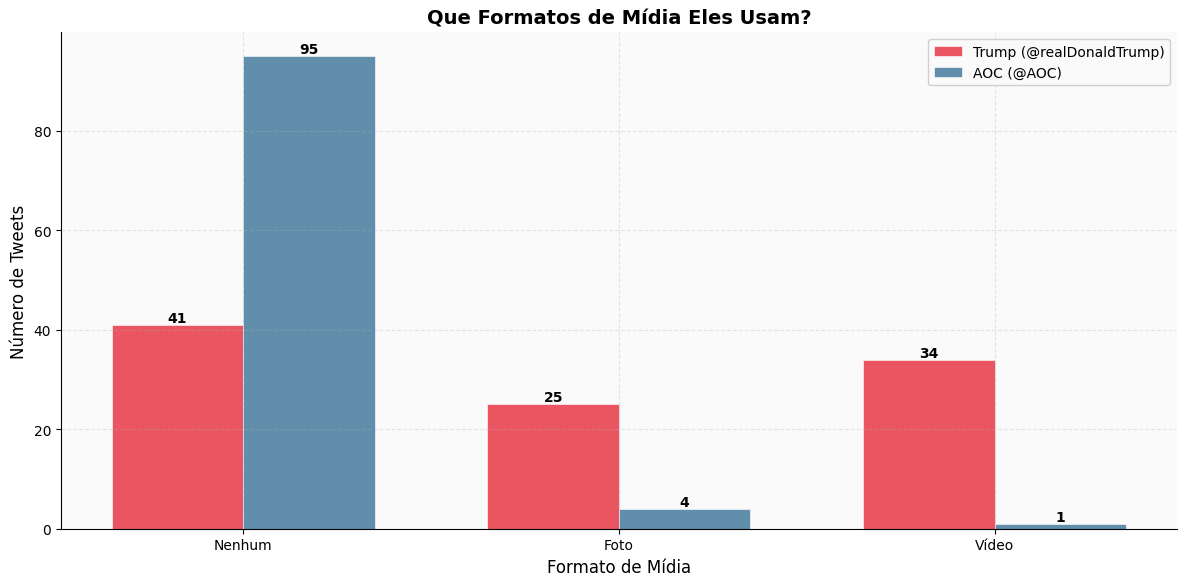

In [9]:
# --- Que Formatos de Mídia Eles Usam? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Obter tipos de mídia únicos entre ambos os usuários
media_types = df['media_type'].cat.categories.tolist() if hasattr(df['media_type'], 'cat') else df['media_type'].unique().tolist()
media_types = sorted([mt for mt in media_types if pd.notna(mt)])

x = np.arange(len(media_types))
bar_width = 0.35

media_labels_map = {'none': 'Nenhum', 'photo': 'Foto', 'video': 'Vídeo', 'mixed': 'Misto', 'animated_gif': 'GIF'}

for i, user in enumerate(['trump', 'aoc']):
    user_data = df[df['user'] == user]
    counts = user_data['media_type'].value_counts().reindex(media_types, fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(
        x + offset, counts.values,
        width=bar_width, color=colors[user], alpha=0.85,
        label=get_user_label(user), edgecolor='white', linewidth=0.5
    )
    # Rótulos de valor
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, height,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=10, fontweight='bold'
            )

ax.set_title('Que Formatos de Mídia Eles Usam?', fontweight='bold', fontsize=14)
ax.set_xlabel('Formato de Mídia')
ax.set_ylabel('Número de Tweets')
ax.set_xticks(x)
ax.set_xticklabels([media_labels_map.get(mt, mt.title()) for mt in media_types])
ax.legend()
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico compara com que frequência cada político usa tweets apenas com texto, fotos, vídeos ou mídia mista. Se um político depende muito de vídeo enquanto o outro prefere texto, isso sugere diferentes abordagens de narrativa digital.

Mídia visual (fotos e vídeos) tende a atrair mais atenção em plataformas de redes sociais porque impede as pessoas de rolar a tela sem parar. Políticos que usam mais conteúdo visual podem estar fazendo uma escolha deliberada de priorizar a captura de atenção em vez de discussão detalhada de políticas.

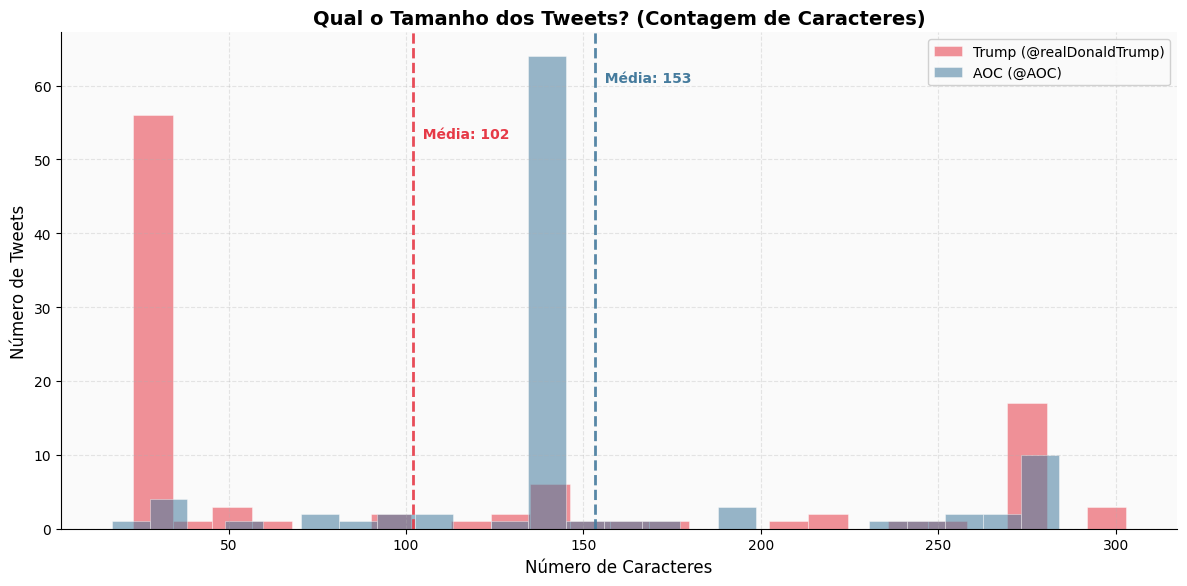

Estatísticas do tamanho dos tweets (em caracteres):
       count   mean    std   min    25%    50%    75%    max
user                                                        
aoc   100.00 153.30  59.50 17.00 140.00 140.00 144.00 284.00
trump 100.00 102.00 105.50 23.00  23.00  23.00 178.80 303.00


In [10]:
# --- Qual o Tamanho dos Tweets? (Contagem de Caracteres) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['text_length'].dropna()
    ax.hist(
        user_data, bins=25, alpha=0.55,
        color=colors[user], edgecolor='white', linewidth=0.5,
        label=get_user_label(user)
    )
    # Linha vertical da média
    mean_val = user_data.mean()
    ax.axvline(
        mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.9
    )
    ax.text(
        mean_val, ax.get_ylim()[1] * 0.9,
        f'  Média: {mean_val:.0f}',
        color=colors[user], fontsize=10, fontweight='bold'
    )

ax.set_title('Qual o Tamanho dos Tweets? (Contagem de Caracteres)', fontweight='bold', fontsize=14)
ax.set_xlabel('Número de Caracteres')
ax.set_ylabel('Número de Tweets')
ax.legend()
plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("Estatísticas do tamanho dos tweets (em caracteres):")
print(df.groupby('user')['text_length'].describe().round(1).to_string())

### O que isso nos diz?

Este gráfico mostra como os tamanhos dos tweets se distribuem para cada político. As linhas tracejadas mostram o tamanho médio. Se as barras estão agrupadas à esquerda, significa que a maioria dos tweets é curta. Se se espalham por toda a faixa, significa que o político usa tanto declarações curtas e incisivas quanto posts mais longos e detalhados.

Na comunicação política, a brevidade sempre foi poderosa -- pense em slogans como "Yes We Can" ou "Make America Great Again". Mas as redes sociais também permitem threads e explicações mais longas. O equilíbrio entre tweets curtos e longos revela se um político favorece slogans ou substância.

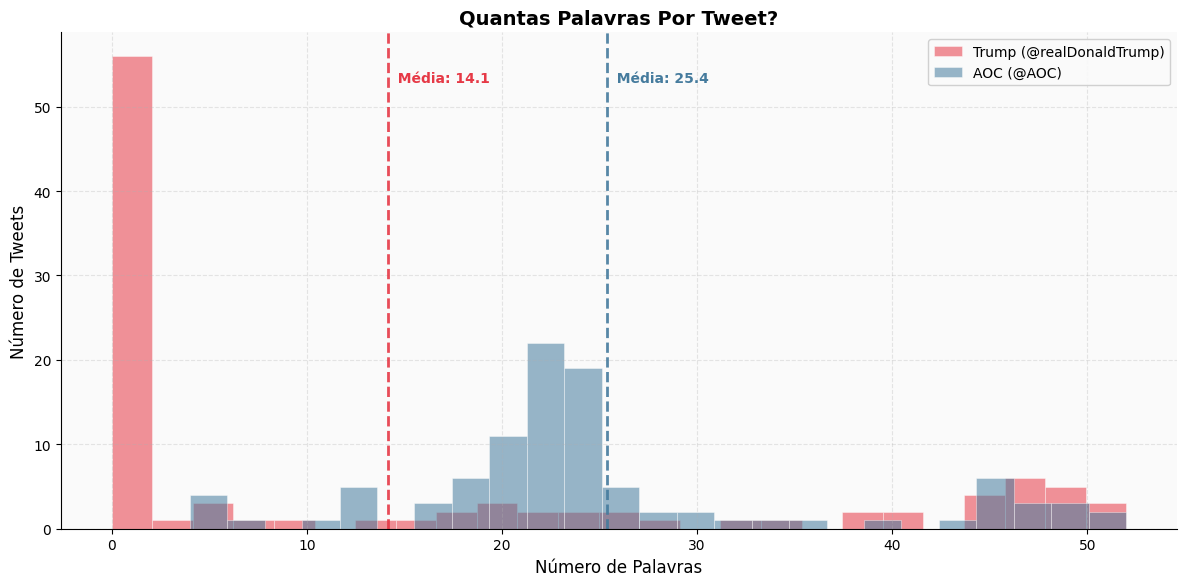

Estatísticas da contagem de palavras:
       count  mean   std  min   25%   50%   75%   max
user                                                 
aoc   100.00 25.40 11.00 4.00 20.00 23.00 26.20 52.00
trump 100.00 14.10 19.00 0.00  0.00  0.00 27.50 52.00


In [11]:
# --- Quantas Palavras Por Tweet? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['word_count'].dropna()
    ax.hist(
        user_data, bins=25, alpha=0.55,
        color=colors[user], edgecolor='white', linewidth=0.5,
        label=get_user_label(user)
    )
    # Linha vertical da média
    mean_val = user_data.mean()
    ax.axvline(
        mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.9
    )
    ax.text(
        mean_val, ax.get_ylim()[1] * 0.9,
        f'  Média: {mean_val:.1f}',
        color=colors[user], fontsize=10, fontweight='bold'
    )

ax.set_title('Quantas Palavras Por Tweet?', fontweight='bold', fontsize=14)
ax.set_xlabel('Número de Palavras')
ax.set_ylabel('Número de Tweets')
ax.legend()
plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("Estatísticas da contagem de palavras:")
print(df.groupby('user')['word_count'].describe().round(1).to_string())

### O que isso nos diz?

Similar à contagem de caracteres, o gráfico de contagem de palavras nos mostra a densidade verbal dos tweets de cada político. Menos palavras por tweet significam uma comunicação mais incisiva, semelhante a slogans. Mais palavras podem significar que o político está explicando posições políticas, contando histórias ou participando de argumentos mais complexos.

Observe se as duas distribuições se sobrepõem muito ou quase nada. Se são muito diferentes, isso confirma que esses dois políticos têm estilos retóricos distintamente diferentes nas redes sociais.

## 5. Comparação Lado a Lado: Os Números em Um Olhar

A tabela abaixo coloca todos os números principais lado a lado para que você possa comparar Trump e AOC diretamente. Para cada métrica, você verá:

- **Média**: O valor típico entre todos os tweets
- **Mediana (valor do meio)**: O valor bem no centro -- útil quando alguns tweets extremos puxam a média para cima ou para baixo
- **Desvio (desvio padrão -- quão espalhados os números estão)**: Um número maior significa mais variação entre os tweets

In [12]:
# --- Tabela Comparativa Lado a Lado ---

metrics = [
    'text_length', 'word_count', 'favorite_count', 'retweet_count',
    'reply_count', 'view_count', 'engagement_rate', 'hashtag_count', 'media_count'
]

metric_labels = {
    'text_length': 'Tamanho do Tweet (caracteres)',
    'word_count': 'Contagem de Palavras',
    'favorite_count': 'Curtidas',
    'retweet_count': 'Repostagens',
    'reply_count': 'Respostas',
    'view_count': 'Visualizações',
    'engagement_rate': 'Taxa de Engajamento (% de espectadores que interagiram)',
    'hashtag_count': 'Hashtags Usadas',
    'media_count': 'Itens de Mídia (fotos/vídeos)'
}

summary_rows = []

for metric in metrics:
    row = {'Métrica': metric_labels.get(metric, metric)}
    for user in ['trump', 'aoc']:
        user_data = df[df['user'] == user][metric].dropna()
        label = 'Trump' if user == 'trump' else 'AOC'
        row[f'{label} Média'] = user_data.mean()
        row[f'{label} Valor Central'] = user_data.median()
        row[f'{label} Desvio'] = user_data.std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Métrica')

# Estilizar a tabela
def style_summary(styler):
    """Aplicar estilização à tabela resumo."""
    styler.format({
        'Trump Média': '{:,.1f}',
        'Trump Valor Central': '{:,.1f}',
        'Trump Desvio': '{:,.1f}',
        'AOC Média': '{:,.1f}',
        'AOC Valor Central': '{:,.1f}',
        'AOC Desvio': '{:,.1f}',
    })
    styler.set_caption('Comparação Lado a Lado: Trump vs AOC')
    styler.set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
    ])
    # Destacar colunas do Trump em tom vermelho, AOC em tom azul
    trump_cols = [c for c in summary_df.columns if c.startswith('Trump')]
    aoc_cols = [c for c in summary_df.columns if c.startswith('AOC')]
    styler.set_properties(subset=trump_cols, **{'background-color': '#fce4e4'})
    styler.set_properties(subset=aoc_cols, **{'background-color': '#e4ecf4'})
    return styler

display(summary_df.style.pipe(style_summary))

# Também imprimir versão em texto simples
print("\nVersão em texto simples:")
print(summary_df.round(1).to_string())

,Trump Média,Trump Valor Central,Trump Desvio,AOC Média,AOC Valor Central,AOC Desvio
Métrica,,,,,,
Tamanho do Tweet (caracteres),102.0,23.0,105.5,153.3,140.0,59.5
Contagem de Palavras,14.1,0.0,19.0,25.4,23.0,11.0
Curtidas,"336,963.4","318,363.0","240,516.8","19,992.7",0.0,"46,261.6"
Repostagens,"45,076.1","40,854.5","27,550.8","7,884.6","4,630.5","9,795.7"
Respostas,"33,032.8","24,303.5","29,559.8","2,171.1",0.0,"5,583.0"
Visualizações,"56,370,009.9","46,802,237.0","39,099,407.6","780,902.0",332.5,"1,737,657.0"
Taxa de Engajamento (% de espectadores que interagiram),1.2,0.0,4.7,946.5,2.4,"3,383.9"
Hashtags Usadas,0.0,0.0,0.1,0.0,0.0,0.1
Itens de Mídia (fotos/vídeos),0.6,1.0,0.6,0.1,0.0,0.4



Versão em texto simples:
                                                          Trump Média  Trump Valor Central  Trump Desvio  AOC Média  AOC Valor Central   AOC Desvio
Métrica                                                                                                                                            
Tamanho do Tweet (caracteres)                                  102.00                23.00        105.50     153.30             140.00        59.50
Contagem de Palavras                                            14.10                 0.00         19.00      25.40              23.00        11.00
Curtidas                                                   336,963.40           318,363.00    240,516.80  19,992.70               0.00    46,261.60
Repostagens                                                 45,076.10            40,854.50     27,550.80   7,884.60           4,630.50     9,795.70
Respostas                                                   33,032.80            24,30

### O que isso nos diz?

Esta tabela é sua "cola" para comparar os dois políticos. Algumas coisas para observar:

- **Visualizações**: Qual político alcança mais pessoas por tweet? Isso reflete o tamanho geral de sua audiência e visibilidade na plataforma.
- **Curtidas vs. Repostagens**: Curtidas são uma forma rápida e de baixo esforço de aprovação. Repostagens exigem que o espectador ativamente compartilhe o conteúdo. Uma alta proporção de repostagens em relação a curtidas sugere conteúdo que as pessoas querem espalhar, não apenas reconhecer.
- **Taxa de Engajamento**: Este é talvez o número mais revelador. Mesmo que um político tenha mais visualizações totais, o outro pode ter uma taxa de engajamento mais alta -- significando que sua audiência é mais ativamente envolvida.
- **Desvio (desvio padrão)**: Valores grandes de desvio significam que o político tem uma mistura de tweets com alto e baixo desempenho. Desvio pequeno significa mais consistência.

## 6. Principais Conclusões: O Que Aprendemos Com Este Primeiro Olhar

Após explorar os dados, aqui estão as principais observações desta análise inicial:

- **Duas personas digitais muito diferentes**: Mesmo antes de analisar o conteúdo dos tweets, os dados estruturais revelam que Trump e AOC usam o Twitter de maneiras fundamentalmente diferentes. Eles diferem nos horários de postagem, tipos de tweet, preferências de mídia e tamanho dos tweets -- sugerindo estratégias distintas de comunicação digital.

- **Transmissão vs. conversa**: O detalhamento dos tipos de tweet mostra se cada político primariamente transmite mensagens originais ou se engaja em diálogo por meio de respostas e citações. Esta distinção mapeia uma tensão clássica na comunicação política entre mensagens de cima para baixo e engajamento participativo.

- **Ritmos diários diferentes**: Os gráficos de hora do dia e dia da semana revelam padrões de postagem distintos. Esses ritmos refletem não apenas hábitos pessoais, mas escolhas estratégicas sobre quando alcançar as audiências. Um político que posta nos horários de pico está competindo por atenção; um que posta fora do horário de pico pode estar mirando seguidores dedicados que verificam seu feed a qualquer hora.

- **Escolhas de formato de mídia refletem estilo de comunicação**: O equilíbrio entre posts apenas com texto e mídia visual (fotos, vídeos) nos diz sobre a abordagem de cada político à narrativa digital. Conteúdo visual tende a ter melhor desempenho em feeds algorítmicos, então uma preferência por posts ricos em mídia pode indicar comunicação mais experiente com a plataforma.

- **Tamanho do tweet como estratégia retórica**: As distribuições de contagem de caracteres e palavras mostram se cada político favorece declarações curtas e incisivas (mais próximas de slogans) ou posts mais longos e elaborados (mais próximos de ensaios ou explicações de políticas). Isso tem implicações para como suas mensagens são consumidas e compartilhadas.

- **Escala da audiência**: As contagens brutas de visualizações e os números de engajamento revelam a enorme escala do alcance digital desses políticos. Mesmo em nossa amostra de 100 tweets cada, estamos olhando para milhões de visualizações e centenas de milhares de interações -- números que rivalizam com audiências da mídia tradicional.

- **Consistência vs. variabilidade**: O desvio (desvio padrão) nas métricas de engajamento nos diz se um político recebe respostas consistentemente similares ou se tem acertos e erros dramáticos. Alta variabilidade sugere que alguns conteúdos ressoam muito mais fortemente do que outros, o que vale a pena investigar mais a fundo.

### O Que Vem a Seguir

Este notebook nos deu uma visão geral do terreno. Nos próximos notebooks, aprofundaremos mais:

- **Notebook 2**: Quem recebe mais atenção? Um olhar detalhado sobre engajamento (curtidas, repostagens, respostas) e o que o impulsiona
- **Notebook 3**: Sobre o que eles realmente falam? Análise de conteúdo e linguagem
- **Notebook 4**: O que as pessoas dizem? Padrões de rede e interação
- **Notebook 5**: Reunindo tudo -- um retrato comparativo da comunicação política digital

---

*Nota: Este estudo trata as postagens em redes sociais como artefatos culturais -- fontes primárias para entender a comunicação política contemporânea. A amostra de 100 tweets por político fornece um retrato do comportamento digital recente, assim como um historiador poderia analisar uma seleção de cartas ou discursos para entender a persona pública de uma figura política.*